In [67]:
import tensorflow as tf

In [68]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [69]:
data=ImageDataGenerator(
    rescale=1./255.0,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [70]:
train=data.flow_from_directory(
    './Files',
    target_size=(150,150),
    batch_size=32,
    shuffle=True,
    subset='training',
    class_mode='binary'
    
)
test=data.flow_from_directory(
    './Files',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [71]:
x_train_start,y_train_start=next(train)
x_train_start.shape

(32, 150, 150, 3)

In [72]:
y_train_start.shape

(32,)

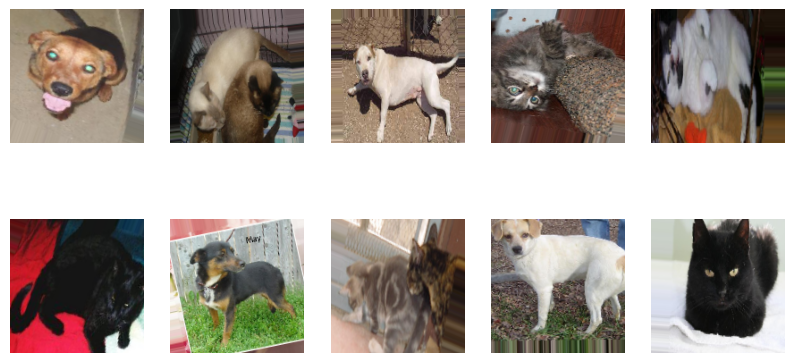

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train_start[i])
    plt.axis('off')

In [74]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [75]:
model=Sequential([
    Input(shape=(150,150,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

In [76]:
from tensorflow.keras.optimizers import Adam
optimizer=Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [77]:
from tensorflow.keras.callbacks import EarlyStopping

In [78]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.001,
    verbose=1,
    restore_best_weights=True
)

In [79]:
history=model.fit(
    train,
    epochs=25,
    validation_data=test,
    callbacks=early_stop
)

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 745ms/step - accuracy: 0.5387 - loss: 0.6859 - val_accuracy: 0.5775 - val_loss: 0.6611
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 740ms/step - accuracy: 0.6266 - loss: 0.6481 - val_accuracy: 0.6350 - val_loss: 0.6266
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 766ms/step - accuracy: 0.6622 - loss: 0.6107 - val_accuracy: 0.6862 - val_loss: 0.5989
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 784ms/step - accuracy: 0.6984 - loss: 0.5773 - val_accuracy: 0.6737 - val_loss: 0.6133
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 769ms/step - accuracy: 0.6991 - loss: 0.5833 - val_accuracy: 0.6587 - val_loss: 0.5886
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 763ms/step - accuracy: 0.7337 - loss: 0.5449 - val_accuracy: 0.7350 - val_loss: 0.5471
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 750ms/step - accuracy: 0.7300 - loss: 0.5417 - val_accuracy: 0.7262 - val_loss: 0.5373
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 728ms/step - accuracy: 0.7412 - loss: 0

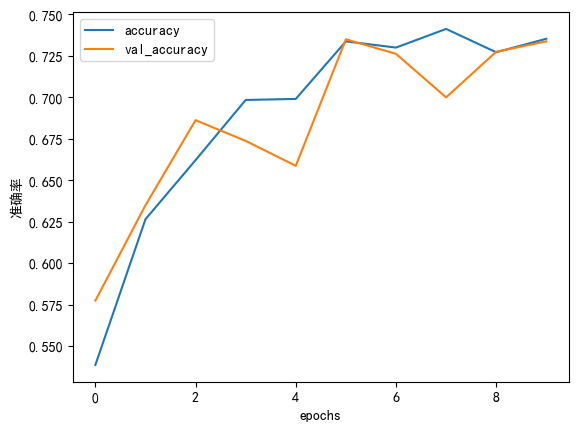

In [80]:
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('epochs')
plt.ylabel('准确率')
plt.legend()

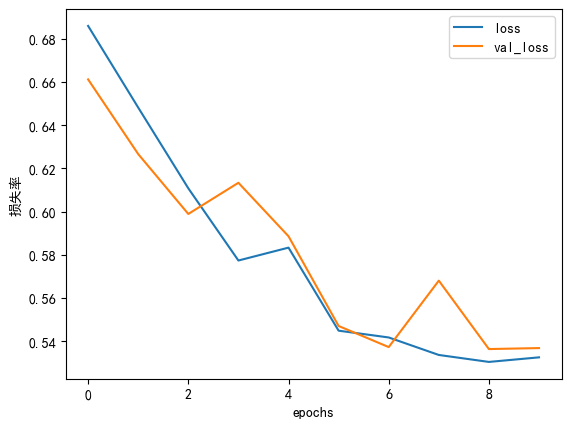

In [81]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('epochs')
plt.ylabel('损失率')
plt.legend()

In [82]:
model.save('cat_dog_model.keras')

In [83]:
train.class_indices

{'cats': 0, 'dogs': 1}

In [84]:
from tensorflow.keras import models

In [85]:
load_model=models.load_model('./cat_dog_model.keras')

In [86]:
from tensorflow.keras.preprocessing import image

In [87]:
img=image.load_img('./img1.jpeg',target_size=(150,150))
img_array=image.img_to_array(img)
img_array.shape

(150, 150, 3)

In [88]:
img_array=img_array.reshape(1,150,150,3)
img_array.shape

(1, 150, 150, 3)

In [89]:
img_array=img_array/255.0

In [90]:
result=load_model.predict(img_array)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


array([[0.31318122]], dtype=float32)

In [91]:
print('预测的结果是：','猫' if result[0]<=0.5 else '狗')

预测的结果是： 猫
